In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/ds_salaries.csv")

In [3]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [5]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [6]:
df.shape

(607, 12)

In [7]:
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop(columns=['Unnamed: 0'])

KeyError: "['Unnamed: 0'] not found in axis"

In [11]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [12]:
df['job_title'].value_counts()

job_title
Data Scientist                              143
Data Engineer                               132
Data Analyst                                 97
Machine Learning Engineer                    41
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Big Data Engineer                             8
Machine Learning Scientist                    8
Principal Data Scientist                      7
AI Scientist                                  7
Data Science Consultant                       7
Director of Data Science                      7
Data Analytics Manager                        7
ML Engineer                                   6
Computer Vision Engineer                      6
BI Data Analyst                               6
Lead Data Engineer                            6
Data Engineering Manager                      5
Business Data Analyst                         5
Head of Data                  

In [13]:
df['job_title'].nunique()

50

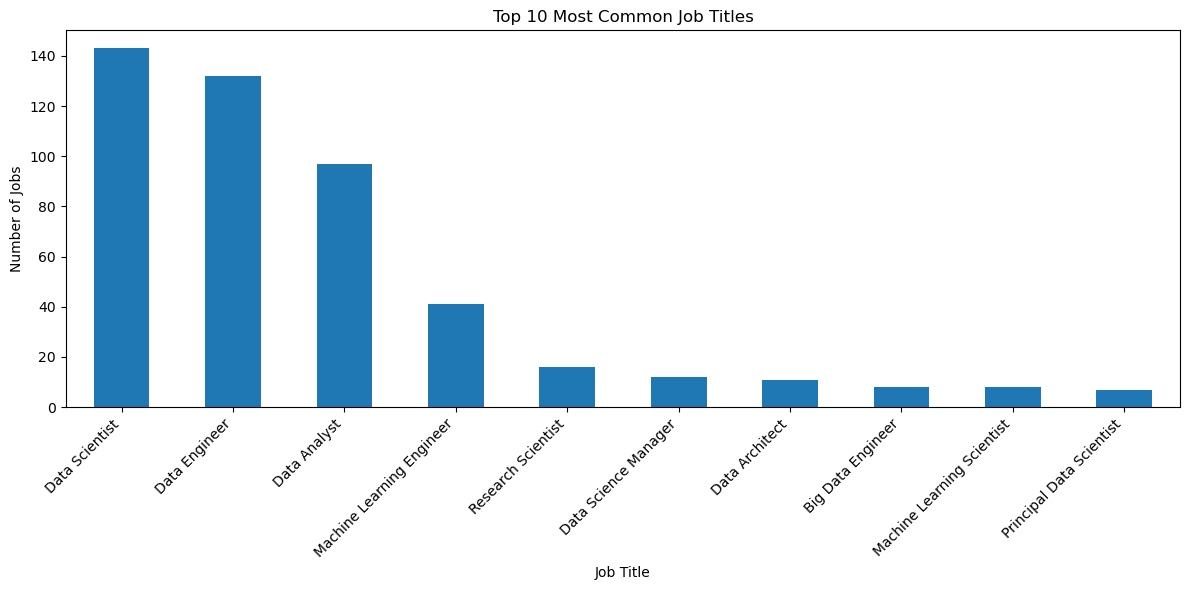

In [14]:
top_jobs = df['job_title'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_jobs.plot(kind='bar')

plt.title('Top 10 Most Common Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Number of Jobs')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

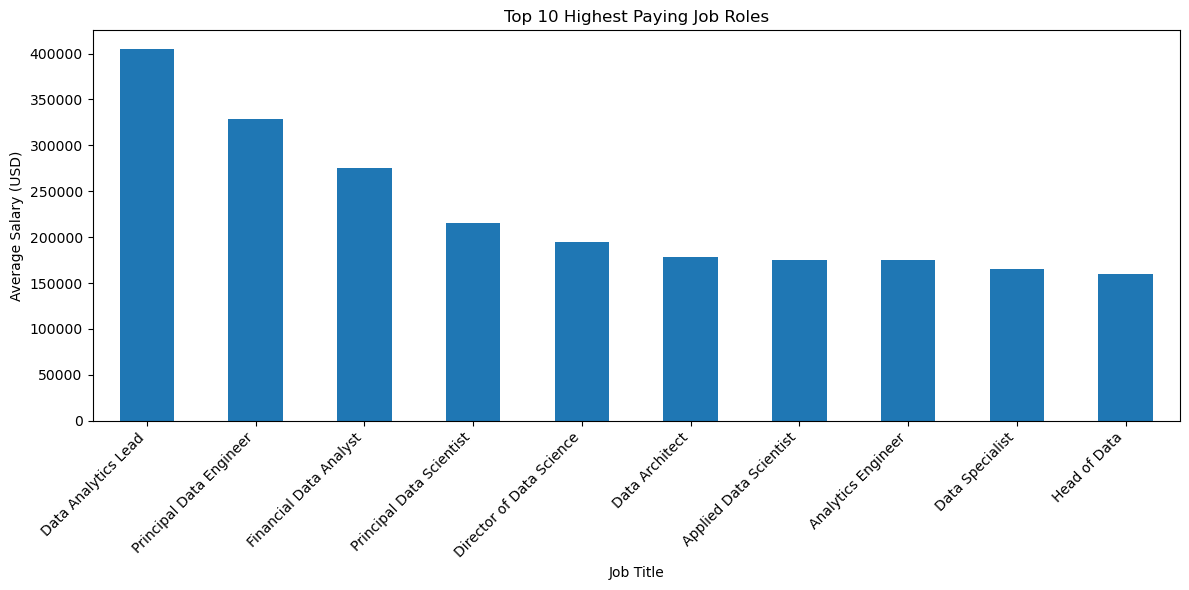

In [15]:
top_salary_jobs = (
    df.groupby('job_title')['salary_in_usd']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_salary_jobs.plot(kind='bar')

plt.title('Top 10 Highest Paying Job Roles')
plt.xlabel('Job Title')
plt.ylabel('Average Salary (USD)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

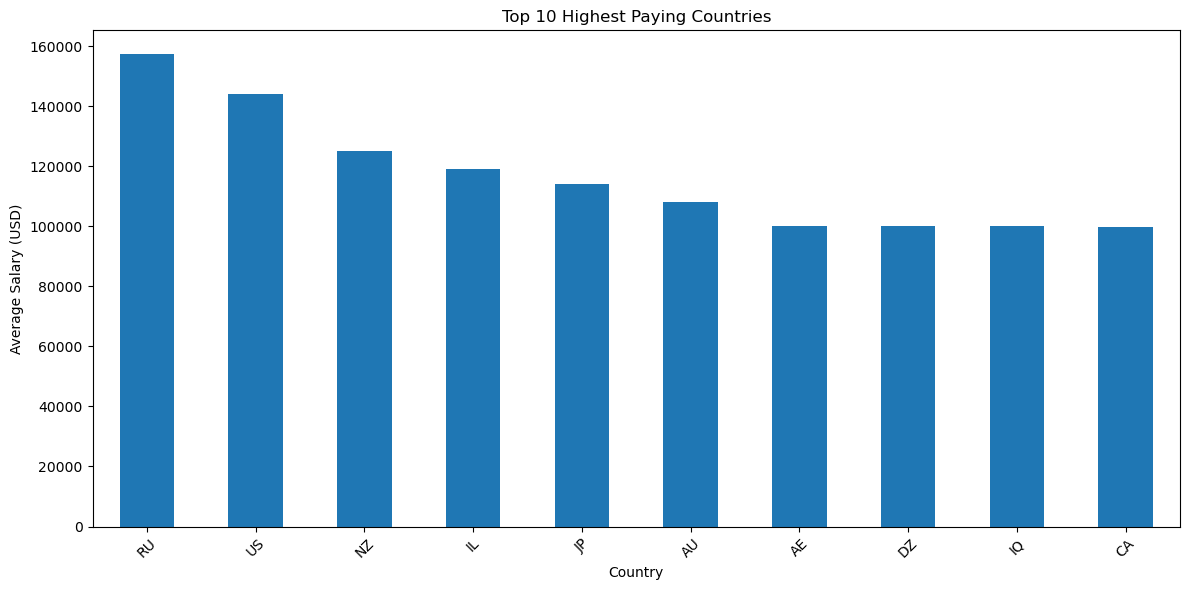

In [16]:
top_countries = (
    df.groupby('company_location')['salary_in_usd']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar')

plt.title('Top 10 Highest Paying Countries')
plt.xlabel('Country')
plt.ylabel('Average Salary (USD)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

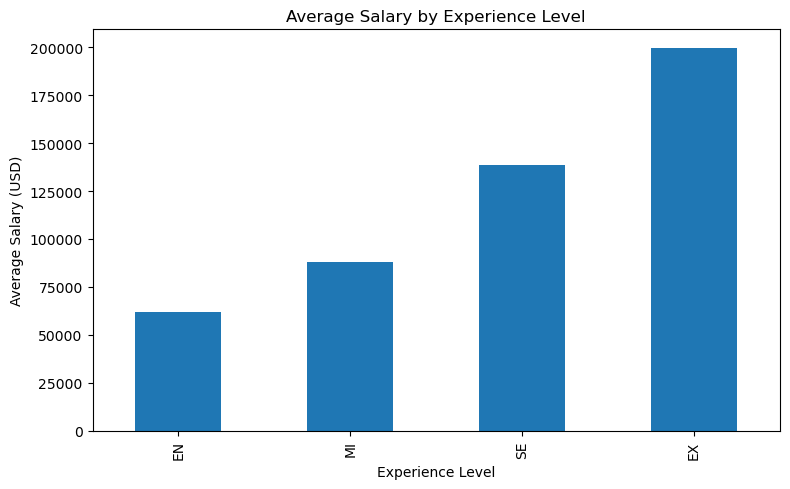

In [17]:
experience_salary = (
    df.groupby('experience_level')['salary_in_usd']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))
experience_salary.plot(kind='bar')

plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')

plt.tight_layout()
plt.show()

In [18]:
df['remote_ratio'].value_counts()

remote_ratio
100    381
0      127
50      99
Name: count, dtype: int64

In [19]:
df['Work_Mode'] = df['remote_ratio'].replace({
    0: 'On-site',
    50: 'Hybrid',
    100: 'Remote'
})

In [20]:
df[['remote_ratio', 'Work_Mode']].head()

,remote_ratio,Work_Mode
0,0,On-site
1,0,On-site
2,50,Hybrid
3,0,On-site
4,50,Hybrid


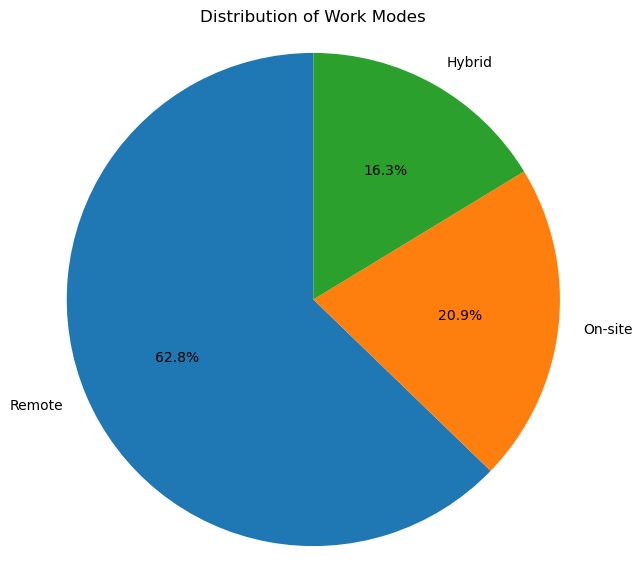

In [21]:
work_mode_counts = df['Work_Mode'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    work_mode_counts,
    labels=work_mode_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Work Modes')
plt.axis('equal')   # Makes the pie chart a perfect circle

plt.show()

In [22]:
company_salary = (
    df.groupby('company_size')['salary_in_usd']
    .mean()
    .sort_values()
)

company_salary

company_size
S     77632.674699
M    116905.466258
L    119242.994949
Name: salary_in_usd, dtype: float64

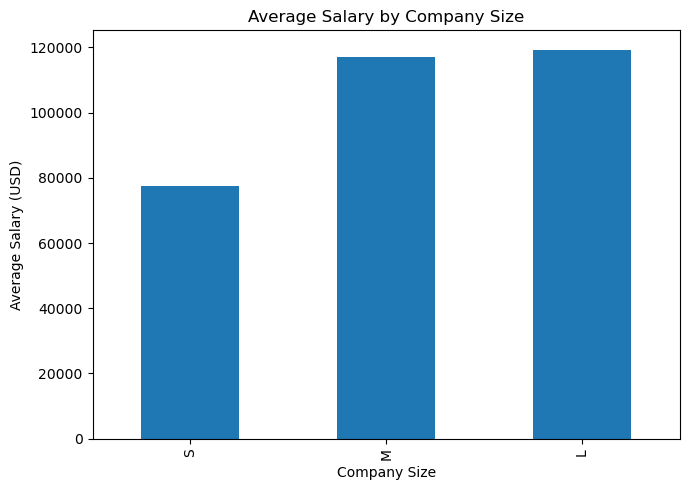

In [23]:
plt.figure(figsize=(7,5))

company_salary.plot(kind='bar')

plt.title('Average Salary by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Average Salary (USD)')

plt.tight_layout()
plt.show()

In [24]:
df.to_csv("../data/job_market_cleaned.csv", index=False)

In [25]:
import os

os.listdir("../data")

['ds_salaries.csv', 'job_market_cleaned.csv']

In [26]:
import os

os.listdir("../data")

['ds_salaries.csv', 'job_market_cleaned.csv']